In [78]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from wordcloud import WordCloud

In [79]:
df = pd.read_csv("/content/twitter_validation.nlp.csv", header=None)
df.columns = ["id", "platform", "sentiment", "text"]

print(df.head())

     id   platform   sentiment  \
0  3364   Facebook  Irrelevant   
1   352     Amazon     Neutral   
2  8312  Microsoft    Negative   
3  4371      CS-GO    Negative   
4  4433     Google     Neutral   

                                                text  
0  I mentioned on Facebook that I was struggling ...  
1  BBC News - Amazon boss Jeff Bezos rejects clai...  
2  @Microsoft Why do I pay for WORD when it funct...  
3  CSGO matchmaking is so full of closet hacking,...  
4  Now the President is slapping Americans in the...  


In [80]:
print("Shape:", df.shape)
print("\nInfo:\n", df.info())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (1000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         1000 non-null   int64 
 1   platform   1000 non-null   object
 2   sentiment  1000 non-null   object
 3   text       1000 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.4+ KB

Info:
 None

Missing Values:
 id           0
platform     0
sentiment    0
text         0
dtype: int64


sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64


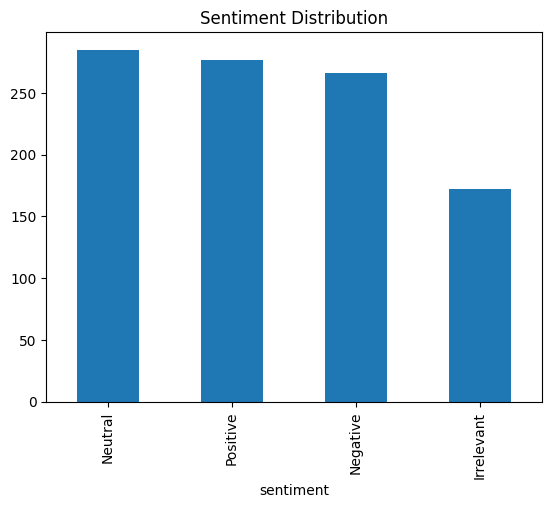

In [81]:
# Target Variable Analysis
print(df["sentiment"].value_counts())

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()

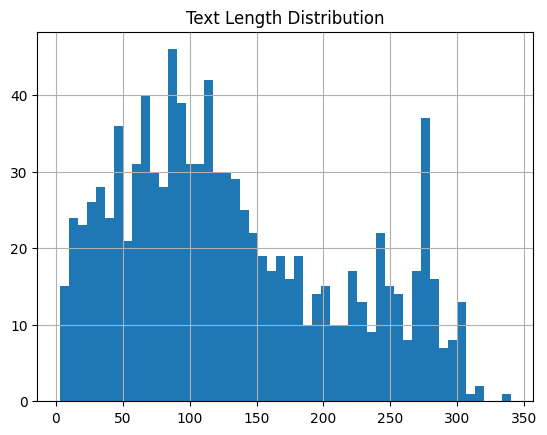

In [82]:
# Text Length Analysis
df["text_length"] = df["text"].apply(lambda x: len(str(x)))

df["text_length"].hist(bins=50)
plt.title("Text Length Distribution")
plt.show()

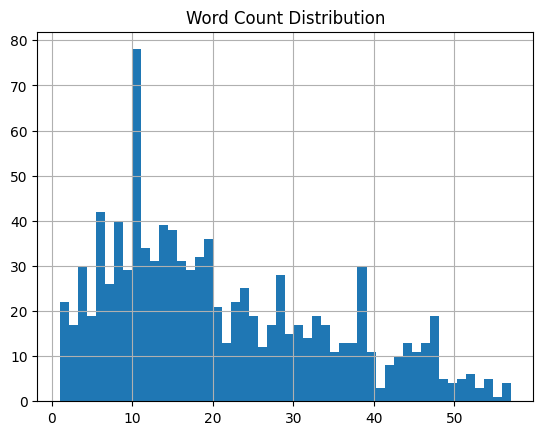

In [83]:
# Word Count Analysis
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

df["word_count"].hist(bins=50)
plt.title("Word Count Distribution")
plt.show()

In [84]:
# Text Cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df["clean_text"] = df["text"].apply(clean_text)


In [85]:
# Most Common Words
all_words = " ".join(df["clean_text"])
words = all_words.split()

common_words = Counter(words).most_common(20)
print(common_words)

[('the', 628), ('to', 432), ('and', 395), ('a', 394), ('i', 372), ('of', 291), ('is', 285), ('for', 238), ('this', 231), ('in', 212), ('it', 187), ('on', 177), ('you', 172), ('my', 157), ('with', 147), ('that', 135), ('me', 112), ('game', 107), ('so', 105), ('have', 89)]


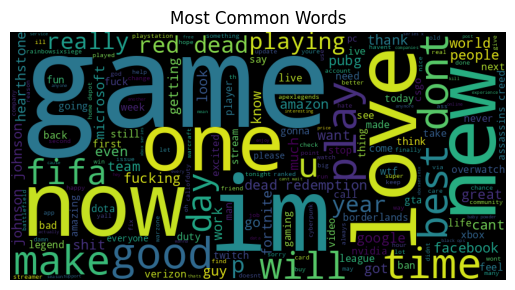

In [86]:
# WordCloud
wordcloud = WordCloud(width=800, height=400).generate(all_words)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words")
plt.show()


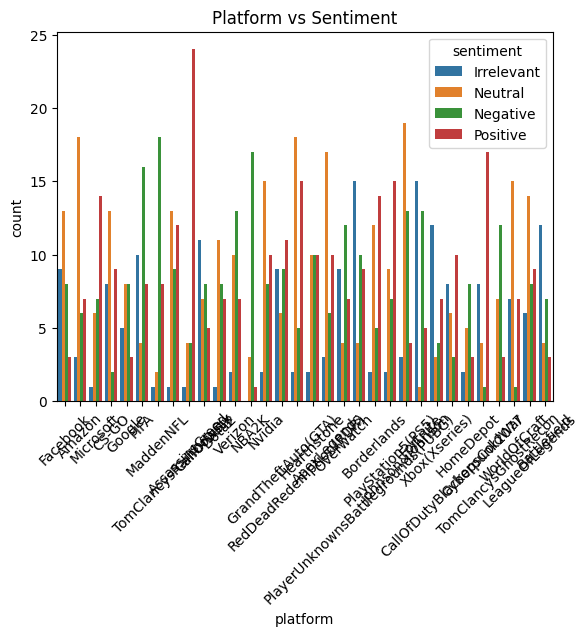

In [87]:
# Platform vs Sentiment
sns.countplot(x="platform", hue="sentiment", data=df)
plt.xticks(rotation=45)
plt.title("Platform vs Sentiment")
plt.show()

In [88]:
# Feature & Label
X = df["clean_text"]
y = df["sentiment"]

In [89]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [90]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [91]:
model = LogisticRegression()
model = LogisticRegression(class_weight='balanced')

In [92]:
# Model Training
model = LogisticRegression()
model.fit(X_train_vec, y_train)


LogisticRegression(class_weight='balanced')

In [93]:
# Prediction
y_pred = model.predict(X_test_vec)

In [94]:
# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.46

Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.26      0.26      0.26        31
    Negative       0.47      0.53      0.50        53
     Neutral       0.53      0.48      0.50        61
    Positive       0.50      0.49      0.50        55

    accuracy                           0.46       200
   macro avg       0.44      0.44      0.44       200
weighted avg       0.46      0.46      0.46       200



In [95]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()

In [96]:
# # custom prediction
def predict_sentiment(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]

print(predict_sentiment("I love this!"))
print(predict_sentiment("Worst experience ever"))

Positive
Negative
